# 📘 Clase 3 · Notebook 3 — Proceso de media móvil MA(q)

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 4**.

| | |
|---|---|
| **Datos** | `widget_sales.csv` — 500 observaciones de ventas de *widgets* (miles de USD), 2019–2020 |
| **Tiempo estimado en casa** | 30 min |
| **¿Se vio en clase?** | ✅ Parcialmente — **Demo 3** (Bloque 2): solo el gráfico ACF (celdas 1–8) |

### 🎯 Al terminar este notebook podrás…
1. Definir un proceso **MA(q)** con una intuición clara.
2. Identificar el orden *q* con la **ACF** (se corta abruptamente después del lag *q*).
3. Implementar un **pronóstico rodante** y compararlo contra baselines.
4. Regresar el pronóstico a la escala original (**invertir la diferenciación**).

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH04/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH04
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **Proceso de media móvil MA(q)**

$$y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \dots + \theta_q\varepsilon_{t-q}$$

El valor de hoy depende de la media $\mu$, del **error (sorpresa) de hoy** y de las **sorpresas de los últimos *q* periodos**.

Analogía: un pedido inesperado y enorme (un *shock*) altera las ventas de hoy y de los próximos días, pero después de *q* días su efecto **desaparece por completo**.

⚠️ No confundir con la “media móvil” para suavizar gráficos (*rolling mean*). Son cosas distintas con el mismo nombre.

🔑 **Firma del MA(q):** en la ACF, las barras son significativas hasta el lag *q* y **luego se cortan de golpe**.

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [14]:
df = pd.read_csv('../data/widget_sales.csv')

df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


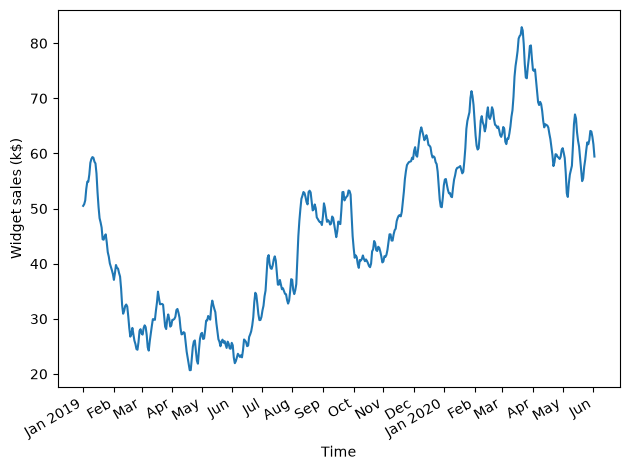

In [15]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F01_peixeiro.png', dpi=300)

🔎 La serie tiene tendencia (sube y baja por tramos largos): candidata a **no** ser estacionaria.

🧭 Paso 1 del procedimiento: **¿es estacionaria?** Prueba ADF.

In [16]:
ADF_result = adfuller(df['widget_sales'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.5121662069359045
p-value: 0.5274845352272606


🔎 p-valor ≈ 0.53 > 0.05 → **no estacionaria**.

🧭 No lo es → **diferenciamos** una vez.

In [17]:
widget_sales_diff = np.diff(df['widget_sales'], n=1)

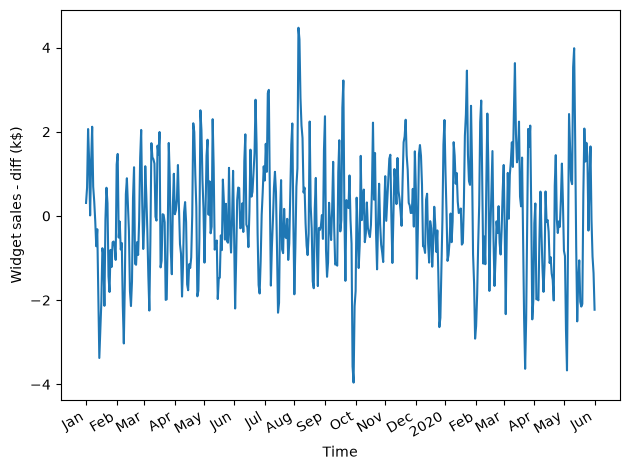

In [18]:
fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F05_peixeiro.png', dpi=300)

In [19]:
ADF_result = adfuller(widget_sales_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19


🔎 p-valor ≈ 0 → la serie diferenciada **es estacionaria**. ✅ Podemos usar la ACF.

🧭 Paso clave: **ACF de la serie diferenciada** para identificar el orden *q*.

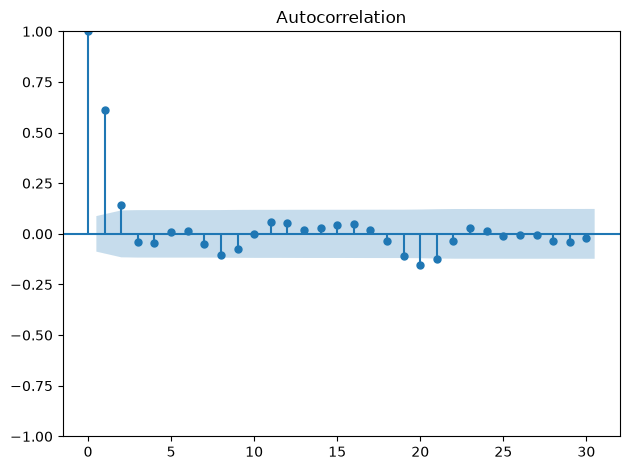

In [20]:
plot_acf(widget_sales_diff, lags=30);

plt.tight_layout()

plt.savefig('figures/CH04_F06_peixeiro.png', dpi=300)

🔎 Barras significativas en los **lags 1 y 2**, y después todas caen dentro de la zona sombreada (el patrón en torno al lag 20 es azar). → El corte abrupto después del lag 2 indica un **MA(2)**.

🧭 División **90 % / 10 %** sobre la serie diferenciada: 449 puntos de train y 50 de test.

In [21]:
df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

train = df_diff[:int(0.9*len(df_diff))]
test = df_diff[int(0.9*len(df_diff)):]

print(len(train))
print(len(test))

449
50


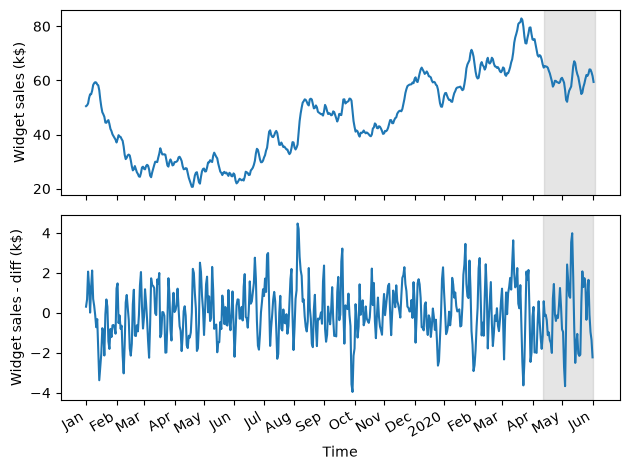

In [22]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F07_peixeiro.png', dpi=300)

💡 **Pronóstico rodante (*rolling forecast*).** En vez de pronosticar los 50 puntos del test de una sola vez, avanzamos de a `N` pasos(`WINDOW = N`):
1. Entrenamos con todo lo conocido hasta el momento *i*.
2. Pronosticamos los siguientes `WINDOW` pasos.
3. “Llegan” los datos reales de esos pasos, los agregamos al entrenamiento y repetimos.

Analogía: el pronóstico del clima se actualiza cada día con la observación nueva; nadie pronostica todo el mes de una sola vez.

⚠️ ¿Por qué `WINDOW = 2`? Un MA(q) solo puede “ver” *q* pasos al futuro: más allá de *q* pasos, su pronóstico es simplemente la media. Con MA(2), pronosticar de a 2 pasos es lo máximo que tiene sentido.

🧭 La función `rolling_forecast` implementa tres métodos para compararlos en igualdad de condiciones: `mean` (media), `last` (último valor) y el modelo estadístico. Dentro del modelo: `get_prediction(0, i + window - 1)` genera predicciones hasta el final de la ventana y `.iloc[-window:]` se queda solo con las **fuera de muestra** (las del futuro).

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'MA':
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)
            
        return pred_MA

In [32]:
pred_df = test.copy()

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


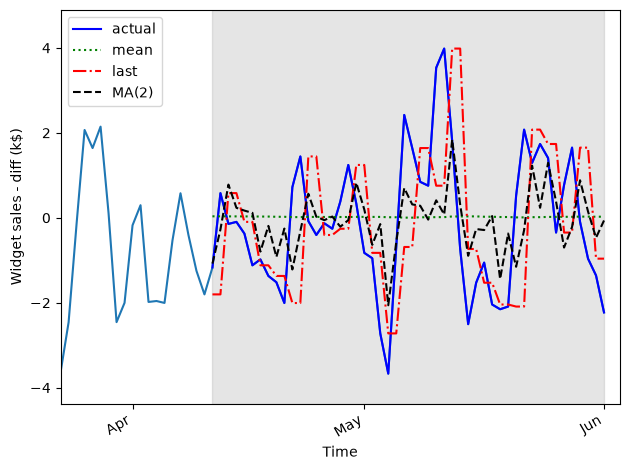

In [33]:
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-.', label='last')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(430, 500)

plt.xticks(
    [439, 468, 498], 
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F08_peixeiro.png', dpi=300)

🧭 Comparamos con el **MSE** (error cuadrático medio) sobre la serie diferenciada.

In [34]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

print(mse_mean, mse_last, mse_MA)

2.5606299456880537 3.2494260812249225 1.9481714497514804


🔎 MSE: media ≈ 2.56, último valor ≈ 3.25, **MA(2) ≈ 1.95**. El modelo MA(2) gana a ambos baselines.

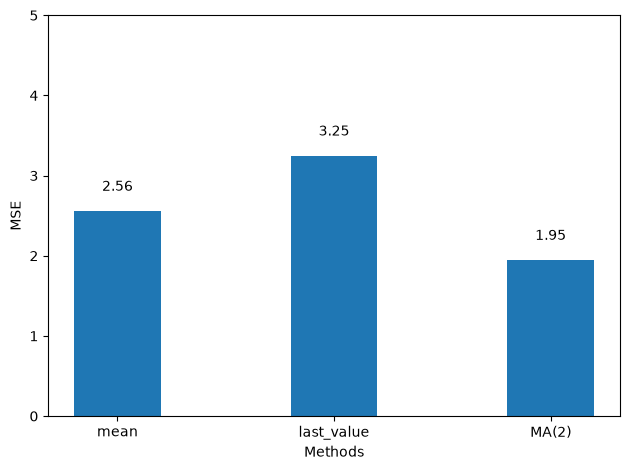

In [35]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH04_F09_peixeiro.png', dpi=300)

💡 **Volver a la escala original (invertir la diferenciación).** El modelo pronosticó **cambios** (sobre la serie diferenciada), pero al negocio le interesan **niveles** (ventas reales). Como diferenciar es restar, deshacerlo es **sumar acumuladamente**: valor inicial + suma acumulada de los cambios pronosticados (`cumsum`).



In [36]:
df['pred_widget_sales'] = np.nan

# 🛠️ .loc en lugar de asignación encadenada (compatible con pandas 2.x / 3.x)
df.loc[450:, 'pred_widget_sales'] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum().values

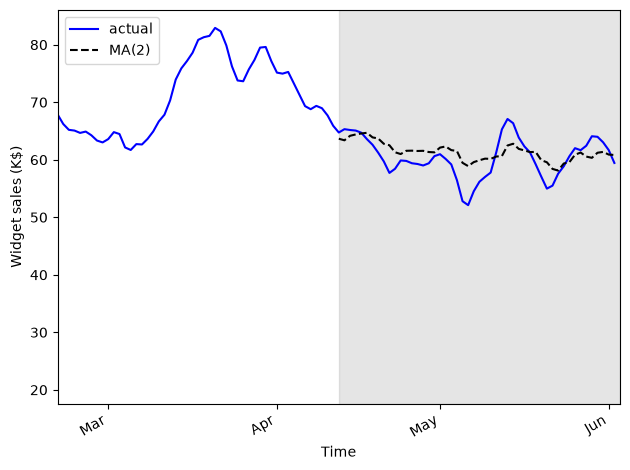

In [37]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')

ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498], 
    ['Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F11_peixeiro.png', dpi=300)

🧭 Error en la **escala original**, con el **MAE** (error absoluto medio, en miles de USD).

In [38]:
from sklearn.metrics import mean_absolute_error

mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:], df['pred_widget_sales'].iloc[450:])

print(mae_MA_undiff)

2.3244709244291437


🔎 MAE ≈ 2.32: en la escala real de ventas, el pronóstico del MA(2) se equivoca en promedio unos 2 320 USD (los datos están en miles de USD).

---
## ✅ Resumen
- **MA(q):** el presente depende de las sorpresas de los últimos *q* periodos.
- **Identificación:** serie estacionaria → ACF → último lag significativo antes del corte = *q*.
- Un MA(q) solo pronostica con sentido hasta *q* pasos → **pronóstico rodante**.
- Para reportar al negocio, invierte la diferenciación (`cumsum`).

🔗 **Siguiente:** ¿y si la ACF **no se corta**, sino que decae lentamente? → proceso **AR** (Capítulo 5).

### 🏠 Ejercicios para casa
Resuelve `CH04_exercises_solution.ipynb` (simular un MA(2) con `ArmaProcess` y pronosticarlo). Intenta primero sin mirar la solución.

### 🧠 Autoevaluación
- ¿Qué patrón de la ACF te dice que la serie es un MA(3)?
- ¿Por qué no tiene sentido pronosticar 10 pasos de una sola vez con un MA(2)?
